In [12]:
pip install pylsl

Note: you may need to restart the kernel to use updated packages.


In [1]:
#!/usr/bin/env python3
"""EEG LSL starter code.

This is intentionally minimal. It only knows how to:
  1. List visible LSL streams on the network.
  2. Connect to an EEG stream by name (or auto-select the only EEG stream).
  3. Pull a fixed-length window of raw samples from that stream.

Everything else -- filtering, feature extraction, classification,
calibration UI, and any output back to Unity or elsewhere -- is left
for you to build on top of this.

Usage:
  python lsl_starter.py streams
  python lsl_starter.py grab --seconds 3
"""

from __future__ import annotations

import argparse
import time

import numpy as np
from pylsl import StreamInlet, resolve_streams

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None


def visible_streams(wait: float = 2.0):
    """Print every LSL stream currently visible on the network."""
    streams = resolve_streams(wait_time=wait)
    for s in streams:
        print(
            f"name={s.name()!r} type={s.type()!r} channels={s.channel_count()} "
            f"rate={s.nominal_srate():g} source_id={s.source_id()!r}"
        )
    return streams


def resolve_eeg(name: str | None, timeout: float) -> StreamInlet:
    """Find and connect to an EEG stream, either by exact name or by type."""
    deadline = time.monotonic() + timeout
    target = f"named {name!r}" if name else "with type 'EEG'"
    print(f"Waiting for an EEG LSL stream {target} ...")
    while time.monotonic() < deadline:
        streams = resolve_streams(wait_time=1.0)
        matches = [
            stream
            for stream in streams
            if (stream.name() == name if name else stream.type().lower() == "eeg")
        ]
        if matches:
            stream = matches[0]
            print(
                f"Connected to {stream.name()!r}: {stream.channel_count()} channels at "
                f"{stream.nominal_srate():g} Hz"
            )
            return StreamInlet(stream, max_buflen=30, processing_flags=0)
    raise TimeoutError(f"No LSL stream {target} appeared within {timeout:g} s")


def parse_channels(text: str | None, channel_count: int) -> np.ndarray:
    """Turn a comma-separated channel list into an index array (or use all channels)."""
    if not text:
        return np.arange(channel_count, dtype=int)
    channels = np.asarray([int(x.strip()) for x in text.split(",")], dtype=int)
    if channels.min() < 0 or channels.max() >= channel_count:
        raise ValueError(f"Channel indices must be between 0 and {channel_count - 1}")
    return channels


def collect_window(inlet: StreamInlet, seconds: float, fs: float, channels: np.ndarray):
    """Block until a window of `seconds` worth of samples has been collected.

    Returns an array shaped (n_channels, n_samples).
    """
    wanted = int(round(seconds * fs))
    samples: list[list[float]] = []
    deadline = time.monotonic() + seconds + 5.0
    while len(samples) < wanted and time.monotonic() < deadline:
        chunk, _ = inlet.pull_chunk(timeout=0.25, max_samples=wanted - len(samples))
        samples.extend(chunk)
    if len(samples) < wanted:
        raise RuntimeError(f"Only received {len(samples)}/{wanted} EEG samples")
    data = np.asarray(samples[:wanted], dtype=float).T
    return data[channels]


def grab(args):
    """Connect to an EEG stream and pull one window of samples, printing its shape."""
    inlet = resolve_eeg(args.eeg_stream, args.timeout)
    info = inlet.info()
    fs = args.sampling_rate or info.nominal_srate()
    if fs <= 0:
        raise ValueError("The stream has no nominal rate; supply --sampling-rate")
    channels = parse_channels(args.channels, info.channel_count())
    epoch = collect_window(inlet, args.seconds, fs, channels)
    print(f"Collected epoch with shape {epoch.shape} (channels x samples) at {fs:g} Hz")

    # ------------------------------------------------------------------
    # SANITY-CHECK SCAFFOLDING -- delete this block once you trust that
    # data is actually arriving and start building your own pipeline.
    # ------------------------------------------------------------------
    print("First few raw samples per channel:")
    for ch_index, ch_data in zip(channels, epoch):
        preview = ", ".join(f"{v:.2f}" for v in ch_data[:5])
        print(f"  ch{ch_index}: {preview} ...")

    if not args.no_plot:
        if plt is None:
            print("matplotlib is not installed; skipping plot (pip install matplotlib)")
        else:
            time_axis = np.arange(epoch.shape[1]) / fs
            fig, ax = plt.subplots()
            for ch_index, ch_data in zip(channels, epoch):
                ax.plot(time_axis, ch_data, label=f"ch{ch_index}")
            ax.set_xlabel("seconds")
            ax.set_ylabel("amplitude")
            ax.set_title("Raw EEG window (sanity check only)")
            ax.legend(loc="upper right", fontsize="small")
            plt.show()
    # ------------------------------------------------------------------
    # END SANITY-CHECK SCAFFOLDING
    # ------------------------------------------------------------------

    # TODO: this is where your own processing / classification pipeline starts.



In [2]:
# import os (this is for Cagla's computer dont run)
import numpy as np

In [3]:
try:
    import scipy.signal as signal
except ImportError:
    signal = None
    print("Warning: scipy is missing")

try:
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
except ImportError:
    LinearDiscriminantAnalysis = None
    print("Warning: scikit-learn is missing")

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("Warning: matplotlib is missing")

In [4]:
def apply_bandpass_filter(data: np.ndarray,
                          fs: float,
                          lowcut: float = 1.0, 
                          highcut: float = 50.0) -> np.ndarray:
    """Step 1: Preprocess. Apply the Butterworth bandpass filter to remove noise."""
    if signal is None:
        return data

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(4, [low, high], btype="band")

    # zero-phase filter along the sample dimension (axis=1) : this ensures the brainwaves
    # don't get shifted left or right in time.
    # filtfilt is a scipy function means forward-backward filter 
    # it runs the data through the filter forward (mainly left to right)
    # then takes that filtered data and runs it through the filter again but this time
    # it is backward (right to left)
    filtered_data = signal.filtfilt(b, a, data, axis=1)
    return filtered_data


def extract_features(data: np.ndarray, fs: float) -> np.ndarray:
    """Step 2: Extract features. Compress raw data into bands (Theta, Alpha, Beta)."""
    if signal is None: # safet check for the data, for scipy package
        return np.zeros(data.shape[0] * 3)

    nperseg = min(int(fs), data.shape[1]) # for number of points per segment, 1 second of the data
    
    # this is maths. uses welch means Welch's method: it converts the data 
    # from the time domain to frequency domain
    # psd (power spectral density) tells how much power or energy the brain is producing at 
    # those frequencies
    freqs, psd = signal.welch(data, fs, nperseg=nperseg)

    bands = {"theta": (4, 8), "alpha": (8, 12), "beta": (13, 30)}
    features = []

    for ch_idx in range(data.shape[0]):
        for band_name, (low, high) in bands.items():
            band_idx = np.logical_and(freqs >= low, freqs <= high) # np.logical_and is np function
            power = np.mean(psd[ch_idx, band_idx]) # psd looks for the current channel, zooms in on
            # only the indices that has been found for the current band and calculates average
            features.append(power)

    return np.asarray(features, dtype=float)

# n_features: the total number of features
# n_features : number of channels (in our case 3) * how many bands (again 3, theta, alpha, beta)
def get_trained_classifier(fs: float, window_sec: float, channels: list): 
    """Step 3: Train/Load Classifier (Left Hand, Right Hand, Leg, Rest)."""
    if LinearDiscriminantAnalysis is None: # safety check
        return None

    calibration_files = {
    
        "Leg": "LegsTraining.csv",
        "Rest": "RestTraining.csv"
    }
    
    x_train = [] # this will hold all feature numbers
    y_train = [] # this will hold the matching answers
    
    window_samples = int(window_sec * fs)
    step_samples = int(window_samples * 0.5)
    
    for label, filename in calibration_files.items():
        print(f" Learning {label.upper()} from {filename}...")
        
        raw_data = load_eeg_csv(filename)
        raw_data = raw_data[channels, :]
        clean_data = apply_bandpass_filter(raw_data, fs, lowcut = 1.0, highcut = 50.0)
        
        total_samples = clean_data.shape[1]
        for start_idx in range(0, total_samples - window_samples + 1, step_samples):
            end_idx = start_idx + window_samples
            epoch = clean_data[:, start_idx:end_idx]
            
            features = extract_features(epoch, fs)
            x_train.append(features)
            y_train.append(label)
            
    if len(x_train) == 0:
        print(" No data found, check for CSV files")
        return None
    
    print(f" Training LDA model on {len(x_train)} real brainwave epochs...")
    classifier = LinearDiscriminantAnalysis()
    classifier.fit(x_train, y_train) # this is the training part, 
    return classifier

In [5]:
def load_eeg_csv(filepath: str) -> np.ndarray:
    """Load EEG data from a CSV file. Returns (n_channels, n_samples)."""

    # read CSV, checking for headers
    # data = []
    data = [np.genfromtxt(filepath, delimiter=",")]
    print(data)
    if np.isnan(data[0]).any():
        data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    # replace any unreadable text, missing cells, or trailing commas (NaNs) with 0.0
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    
    # checking for CSV files, if the CSV file 
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    if data.shape[0] > data.shape[1]:
        data = data.T

    return data


In [6]:
csv_file = "Rest5.csv" 
sampling_rate = 256.0  # Hz
window_sec = 1 # epoch window length in seconds
channel_selection = [2, 3, 4] 


Step 1: Loading EEG recording from Rest5.csv'...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 2.38606398e+05,  1.15300770e+03, -6.10000000e+01, ...,
        -8.60000000e+01,  9.60000000e+01,  0.00000000e+00],
       [ 2.38606400e+05,  1.15301010e+03,  1.16000000e+02, ...,
        -6.60000000e+01,  9.50000000e+01,  0.00000000e+00],
       ...,
       [ 2.38616370e+05,  1.16298040e+03,  3.94000000e+02, ...,
        -3.60000000e+01,  1.44000000e+02,  0.00000000e+00],
       [ 2.38616373e+05,  1.16298310e+03,  2.29000000e+02, ...,
         5.00000000e+00,  1.32000000e+02,  0.00000000e+00],
       [ 2.38616385e+05,  1.16299450e+03,  2.75000000e+02, ...,
        -1.30000000e+01,  1.30000000e+02,  0.00000000e+00]],
      shape=(1249, 11))]
Total channels: 11. Kept 3 selected channels.
Processing 1249 samples (4.88 seconds at 256 Hz)


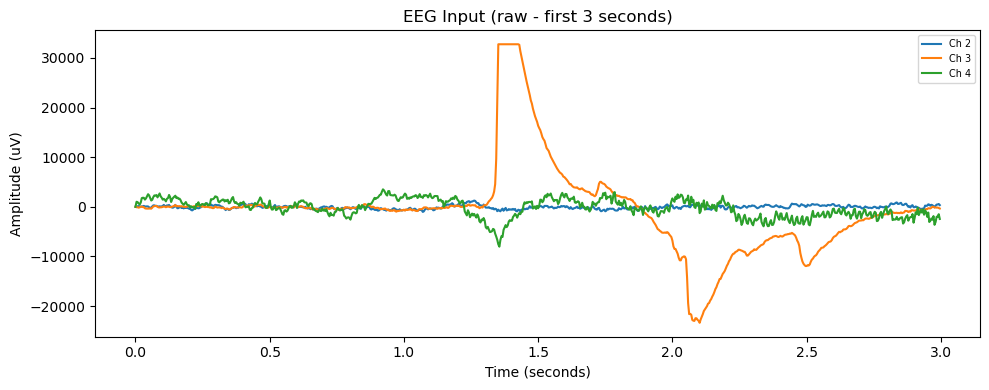

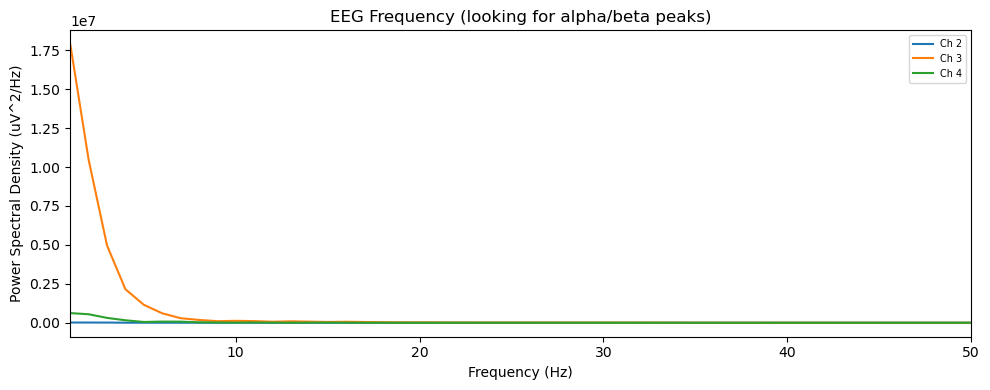

In [7]:
print(f"\nStep 1: Loading EEG recording from {csv_file}'...")
raw_data = load_eeg_csv(csv_file)
channel_count, total_samples = raw_data.shape

# drop the noisy channels
if channel_selection is not None:
    raw_data = raw_data[channel_selection, :]
    
n_channels = raw_data.shape[0]
duration = total_samples / sampling_rate

print(f"Total channels: {channel_count}. Kept {n_channels} selected channels.")
print(f"Processing {total_samples} samples ({duration:.2f} seconds at {sampling_rate:g} Hz)")

if channel_selection:
    channels_to_loop = channel_selection
else:
    channels_to_loop = range(n_channels)

# cleaned EEG data plot
time_axis = np.arange(min(total_samples, int(sampling_rate * 3))) / sampling_rate
fig, ax = plt.subplots(figsize=(10, 4))

for i, ch_idx in enumerate(channels_to_loop):
    ax.plot(time_axis, raw_data[i, :len(time_axis)], label=f"Ch {ch_idx}")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("EEG Input (raw - first 3 seconds)")
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()

# plot the frequencies
fig, ax = plt.subplots(figsize = (10,4))
for i, ch_idx in enumerate(channels_to_loop):
    freqs, psd = signal.welch(raw_data[i, :], fs=sampling_rate, nperseg=int(sampling_rate))
    ax.plot(freqs, psd, label = f"Ch {ch_idx}")
                              
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (uV^2/Hz)")
ax.set_title("EEG Frequency (looking for alpha/beta peaks)")
ax.set_xlim(1, 50)
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()



Step 1: Preprocessing (Bandpass filter: 1.0 - 50.0 Hz)...


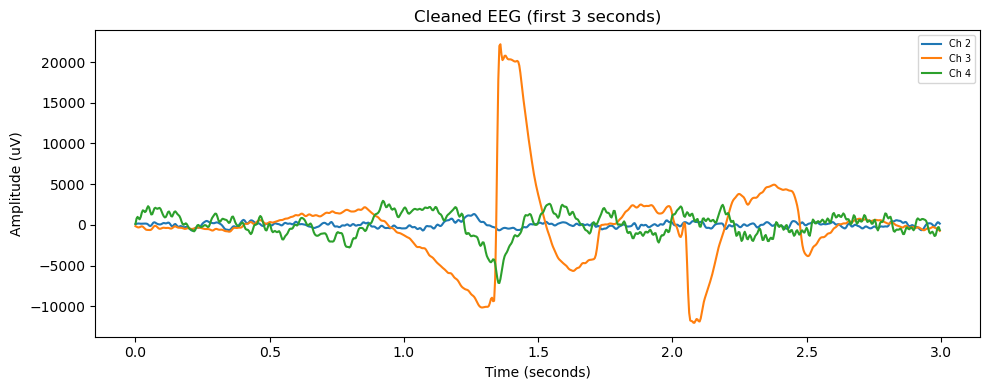

In [8]:
# step 1: preprocess
print("\nStep 1: Preprocessing (Bandpass filter: 1.0 - 50.0 Hz)...")
clean_data = apply_bandpass_filter(raw_data, sampling_rate, lowcut=1.0, highcut=50.0)

total_samples = clean_data.shape[1]
samples_to_plot = min(total_samples, int(sampling_rate * 3))
time_axis = np.arange(samples_to_plot) / sampling_rate

fig, ax = plt.subplots(figsize=(10, 4))

for i, ch_idx in enumerate(channels_to_loop):
    ax.plot(time_axis, clean_data[i, :samples_to_plot], label=f"Ch {ch_idx}")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("Cleaned EEG (first 3 seconds)")
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()


In [9]:
# step 2: setup the classifier
n_features = n_channels * 3  # theta, alpha, beta per channel
classifier = get_trained_classifier(sampling_rate, window_sec, channels_to_loop)

# step 3: slice data, extract features, classify
window_samples = int(window_sec * sampling_rate)
step_samples = int(window_samples * 0.5)  # 50% overlap to not miss any data,
# step_samples: means how far forward the window moves for the next prediction

print(f"\nStep 3: Extracting features & classifying windows ({window_sec}s windows)...")
print("=" * 60)
print(f"{'Time Window':<18} | {'Feature Count':<14} | {'Prediction':<15}")
print("-" * 60)

for start_idx in range(0, total_samples - window_samples + 1, step_samples):
    end_idx = start_idx + window_samples
    epoch = clean_data[:, start_idx:end_idx]
    # epoch: is a short, fixed-length chunk of time chopped out of a continuous stream of data
    features = extract_features(epoch, sampling_rate)
    prediction = classifier.predict([features])[0] if classifier else "N/A"
    # predict is a function of scikit-learn, it tells to model to make a decision at the end, 
    # this is the part when it decides right, left, leg or rest
    
    start_time = start_idx / sampling_rate
    end_time = end_idx / sampling_rate
    print(f"{start_time:5.1f}s - {end_time:5.1f}s   | {len(features):<14} | {prediction.upper()}")

print("=" * 60)
print("\nPipeline execution finished successfully.")

 Learning LEG from LegsTraining.csv...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 9.61471068e+04,  1.08201760e+03,  8.80000000e+01, ...,
         2.10000000e+01, -1.28000000e+02,  0.00000000e+00],
       [ 9.61471082e+04,  1.08201900e+03, -1.78000000e+02, ...,
         1.60000000e+01, -1.37000000e+02,  0.00000000e+00],
       ...,
       [ 9.57300726e+04,  6.64983400e+02, -8.70000000e+02, ...,
        -1.07000000e+02,  4.10000000e+01,  0.00000000e+00],
       [ 9.57300740e+04,  6.64984800e+02, -4.84000000e+02, ...,
        -1.12000000e+02,  1.30000000e+01,  0.00000000e+00],
       [ 9.57300753e+04,  6.64986100e+02, -7.70000000e+02, ...,
        -6.70000000e+01,  1.80000000e+01,  0.00000000e+00]],
      shape=(5073, 11))]
 Learning REST from RestTraining.csv...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 2.38

In [10]:
def build_parser():
    parser = argparse.ArgumentParser(description=__doc__)
    sub = parser.add_subparsers(dest="command")

    streams = sub.add_parser("streams", help="list visible LSL streams")
    streams.add_argument("--wait", type=float, default=2.0)

    common = argparse.ArgumentParser(add_help=False)
    common.add_argument(
        "--eeg-stream",
        help="LSL stream name; omit to auto-select the sole stream of type EEG",
    )
    common.add_argument("--timeout", type=float, default=30.0)

    grab_cmd = sub.add_parser("grab", parents=[common], help="pull one window of raw samples")
    grab_cmd.add_argument("--sampling-rate", type=float)
    grab_cmd.add_argument("--channels", help="zero-based indices, e.g. 0,1,2,3,4,5,6,7")
    grab_cmd.add_argument("--seconds", type=float, default=3.0)
    grab_cmd.add_argument(
        "--no-plot", action="store_true", help="skip the sanity-check plot of the raw epoch"
    )

    return parser


def main():
    parser = build_parser()
    args = parser.parse_args()
    if args.command is None:
        # No subcommand given (e.g. just pressing "Run") -- default to a
        # quick connect-and-grab so it's obvious the setup is working.
        args = parser.parse_args(["grab"])
    if args.command == "streams":
        visible_streams(args.wait)
    elif args.command == "grab":
        grab(args)
    else:
        parser.print_help()


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] {streams,grab} ...
ipykernel_launcher.py: error: argument command: invalid choice: 'C:\\Users\\Owner\\AppData\\Roaming\\jupyter\\runtime\\kernel-4c0829b6-006d-4aa5-a9ab-6644ce169d9c.json' (choose from streams, grab)


SystemExit: 2

C:\Users\Owner\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
"""
Dummy input sender for testing LSLInputReceiver.cs (or LSL4UnityBirdInlet.cs).

Publishes a single-channel LSL stream and pushes a "flap" sample every time
you press Enter, and an "idle" sample right after — mimicking a real
classifier that briefly reports "flap" then returns to idle.

Requires pylsl:
    pip install pylsl

Usage:
    python lsl_dummy_input.py
"""

import time
from pylsl import StreamInfo, StreamOutlet

STREAM_NAME = "MotorImagery"   # must match streamName in LSLInputReceiver.cs
STREAM_TYPE = "Markers"
CHANNEL_COUNT = 1
SAMPLE_RATE = 0                # irregular rate — we push samples manually, not on a clock

FLAP_VALUE = 1.0                # must match flapValue in LSLInputReceiver.cs
IDLE_VALUE = 0.0

info = StreamInfo(STREAM_NAME, STREAM_TYPE, CHANNEL_COUNT, SAMPLE_RATE, "float32", "dummy-source-001")
outlet = StreamOutlet(info)

print(f"Publishing LSL stream '{STREAM_NAME}' (type '{STREAM_TYPE}')")
print("Unity should detect this automatically within a couple of seconds.")
print("Press Enter to push a flap sample. Type 'q' then Enter to quit.\n")

while True:
    user_input = input("> ")
    if user_input.strip().lower() == "q":
        break

    outlet.push_sample([FLAP_VALUE])
    print(f"Pushed flap ({FLAP_VALUE})")

    # Briefly return to idle, similar to a real classifier's output between detections
    time.sleep(0.05)
    outlet.push_sample([IDLE_VALUE])

print("Closed.")

Publishing LSL stream 'MotorImagery' (type 'Markers')
Unity should detect this automatically within a couple of seconds.
Press Enter to push a flap sample. Type 'q' then Enter to quit.

